# Optimización computacional

La guía (§4) pide analizar la complejidad de entrenamiento e inferencia de cada modelo y
contrastarla con tiempos medidos, probar variantes más eficientes de cada uno, estudiar la
paralelización, perfilar el código y resumirlo todo en una tabla de versión estándar frente a
versión optimizada. Los experimentos están en `computo.py`. Se ejecutan con los hiperparámetros
finales de la mejor combinación de cada modelo, sobre el entrenamiento completo, y miden con
tiempos de reloj la mediana de varias repeticiones. Para que esos tiempos sean válidos, el guion
espera a que el equipo no esté corriendo ningún otro experimento.

In [1]:
import json
import sys
import warnings
from pathlib import Path

RAIZ = Path.cwd().parent
sys.path.insert(0, str(RAIZ))
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from scipy import stats

from src import graficos, modelos
from src.analisis import NOMBRES_MODELO
from src.formato import dec, ent, enumerar, pct

graficos.estilo()
pd.set_option('display.float_format', lambda v: f'{v:,.4f}')
CARPETA = RAIZ / 'resultados' / 'computo'


def leer(nombre):
    ruta = CARPETA / f'{nombre}.csv'
    if not ruta.exists():
        display(Markdown(f'*Resultado pendiente: `{nombre}` todavía no se ha medido (lo produce `computo.py`).*'))
        return None
    return pd.read_csv(ruta)


if (CARPETA / 'equipo.json').exists():
    equipo = json.loads((CARPETA / 'equipo.json').read_text(encoding='utf-8'))
    display(pd.Series(equipo).to_frame('equipo de medición'))

,equipo de medición
procesador,"AMD64 Family 23 Model 113 Stepping 0, Authenti..."
nucleos_logicos,6
nucleos_fisicos,6
memoria_gb,15.9000
sistema,Windows-11-10.0.26200-SP0
python,3.13.3
gpu,"NVIDIA GeForce RTX 3050, 6144 MiB"


## 1. Complejidad teórica frente a tiempos medidos

Si el tiempo de entrenamiento crece como $O(n^a)$, en escala log-log es una recta de pendiente $a$.
Se entrena cada modelo con 2.500 a 38.978 clientes y se estima la pendiente con los tamaños
mayores, donde los costes fijos ya no dominan. La inferencia se mide siempre sobre los 9.745 clientes
de prueba.

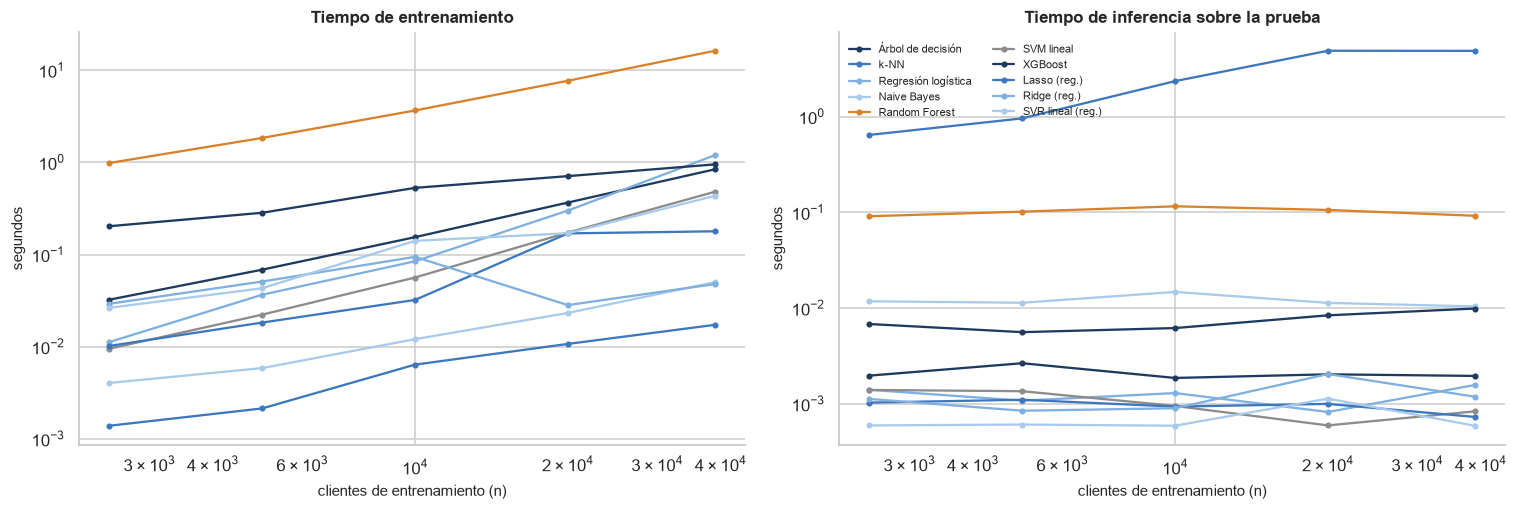

complejidad de entrenamiento  \
tarea         modelo                                                                   
clasificacion Árbol de decisión                                         O(n·p·log n)   
              k-NN                      O(1) fuerza bruta; O(n·p·log n) KD/Ball Tree   
              Regresión logística                O(k·n·p) (liblinear, k iteraciones)   
              Naive Bayes                                                     O(n·p)   
              Random Forest                                           O(T·n·p·log n)   
              SVM lineal                   O(k·n·p) lineal; O(n²·p)–O(n³) con núcleo   
              XGBoost              O(T·d·(n·p + bins·p)) con hist; O(T·d·n·p·log ...   
regresion     Lasso                                O(k·n·p) descenso por coordenadas   
              Ridge                             O(n·p² + p³) cholesky; O(k·n·p) SAGA   
              SVR lineal                   O(k·n·p) lineal; O(n²·p)–O(n³) con núcleo   

                                   pendiente medida (entrenamiento)  \
tarea         modelo                                                  
clasificacion Árbol de decisión                              1.2240   
              k-NN                                           0.9910   
              Regresión logística                            1.7095   
              Naive Bayes                                    1.0355   
              Random Forest                                  1.0616   
              SVM lineal                                     1.5078   
              XGBoost                                        0.5726   
regresion     Lasso                                          1.2435   
              Ridge                                         -0.2050   
              SVR lineal                                     1.0386   

                                                           complejidad de inferencia  \
tarea         modelo                                                                   
clasificacion Árbol de decisión                                    O(d) por consulta   
              k-NN                 O(n·p) por consulta en fuerza bruta; O(p·log n...   
              Regresión logística                                               O(p)   
              Naive Bayes                                   O(p·clases) por consulta   
              Random Forest                                      O(T·d) por consulta   
              SVM lineal                              O(p) lineal; O(s·p) con núcleo   
              XGBoost                                            O(T·d) por consulta   
regresion     Lasso                                                             O(p)   
              Ridge                                                             O(p)   
              SVR lineal                              O(p) lineal; O(s·p) con núcleo   

                                   pendiente medida (inferencia frente al n de entrenamiento)  \
tarea         modelo                                                                            
clasificacion Árbol de decisión                                              -0.1215            
              k-NN                                                            0.8203            
              Regresión logística                                             0.0970            
              Naive Bayes                                                    -0.0766            
              Random Forest                                                  -0.0553            
              SVM lineal                                                     -0.2828            
              XGBoost                                                         0.2936            
regresion     Lasso                                                          -0.1708            
              Ridge                                                           0.2702            
              SVR line

In [2]:
esc = leer('escalamiento')
if esc is not None:
    teoria = {('clasificacion', m): s.complejidad for m, s in modelos.catalogo('clasificacion').items()}
    teoria |= {('regresion', m): s.complejidad for m, s in modelos.catalogo('regresion').items()}
    fig, ax = plt.subplots(1, 2, figsize=(14, 4.8))
    filas = []
    for (tarea, m), g in esc.groupby(['tarea', 'modelo']):
        g = g.sort_values('n')
        etiqueta = f'{NOMBRES_MODELO[m]}{" (reg.)" if tarea == "regresion" else ""}'
        ax[0].plot(g['n'], g['entrenamiento_s'], marker='o', ms=3, label=etiqueta)
        ax[1].plot(g['n'], g['inferencia_s'], marker='o', ms=3, label=etiqueta)
        grandes = g[g['n'] >= g['n'].max() / 8]
        pendiente = np.polyfit(np.log(grandes['n']), np.log(grandes['entrenamiento_s']), 1)[0] if len(grandes) >= 2 else np.nan
        pend_inf = np.polyfit(np.log(grandes['n']), np.log(grandes['inferencia_s']), 1)[0] if len(grandes) >= 2 else np.nan
        ultimo = g.iloc[-1]
        filas.append({'tarea': tarea, 'modelo': NOMBRES_MODELO[m],
                      'complejidad de entrenamiento': teoria[(tarea, m)].get('entrenamiento', ''),
                      'pendiente medida (entrenamiento)': pendiente,
                      'complejidad de inferencia': teoria[(tarea, m)].get('inferencia', ''),
                      'pendiente medida (inferencia frente al n de entrenamiento)': pend_inf,
                      'entrenamiento con todo (s)': ultimo['entrenamiento_s'],
                      'inferencia de la prueba (s)': ultimo['inferencia_s'],
                      'memoria pico (MB)': ultimo.get('memoria_mb'), 'tamaño del modelo (MB)': ultimo.get('tamano_modelo_mb')})
    for a, t in zip(ax, ('entrenamiento', 'inferencia sobre la prueba')):
        a.set_xscale('log')
        a.set_yscale('log')
        a.set_xlabel('clientes de entrenamiento (n)')
        a.set_ylabel('segundos')
        a.set_title(f'Tiempo de {t}')
    ax[1].legend(frameon=False, fontsize=7, ncol=2)
    plt.tight_layout()
    plt.show()
    complejidad = pd.DataFrame(filas).set_index(['tarea', 'modelo'])
    display(complejidad)

In [3]:
if esc is not None:
    c = complejidad.xs('clasificacion')
    pend = complejidad['pendiente medida (entrenamiento)'].droplevel(0)
    pend = pend[~pend.index.duplicated()]
    casi_lineal = pend[(pend > 0.85) & (pend < 1.3)]
    rapido = pend[pend >= 1.3]
    lento = pend[pend <= 0.85]
    inf = complejidad['inferencia de la prueba (s)']
    ent_ = complejidad['entrenamiento con todo (s)']
    mem = complejidad['memoria pico (MB)']
    tam = complejidad['tamaño del modelo (MB)']
    lista = lambda s: enumerar(f"{m} ({dec(v, 2)})" for m, v in s.sort_values().items())
    display(Markdown(f"""
Crecen de forma casi lineal en n, como predicen O(n·p) y O(n·p·log n), {lista(casi_lineal)}. Crecen más
deprisa {lista(rapido)}: resuelven problemas iterativos (liblinear) que necesitan más iteraciones
cuanto más datos ven, de modo que el coste real es O(k·n·p) con un k que
también crece. Crecen más despacio {lista(lento)}: Ridge resuelve un sistema de 78 × 78 (el término p³ es
despreciable) y tarda milisegundos, así que la medición la dominan costes fijos; XGBoost con `hist`
reparte la construcción de histogramas entre 6 hilos y amortiza mejor el coste fijo de cada árbol cuando
hay más filas. La inferencia es casi instantánea en todos salvo k-NN, que «entrena» solo guardando los datos
y traslada el coste a la consulta: tarda {dec(inf.max(), 2)} s en puntuar la prueba, con una
pendiente de {dec(c.loc['k-NN', 'pendiente medida (inferencia frente al n de entrenamiento)'], 2)} frente al número de clientes guardados, como
corresponde a O(n·m·p). El más caro de entrenar es {ent_.idxmax()[1]} ({dec(ent_.max(), 1)} s){', que es también el más pesado en memoria (' + dec(mem.max(), 0) + ' MB de pico) y en disco (' + dec(tam.max(), 0) + ' MB serializado), por sus 300 árboles profundos' if mem.idxmax() == ent_.idxmax() == tam.idxmax() else ''}.
"""))


Crecen de forma casi lineal en n, como predicen O(n·p) y O(n·p·log n), k-NN (0,99), Naive Bayes (1,04), SVR lineal (1,04), Random Forest (1,06), Árbol de decisión (1,22) y Lasso (1,24). Crecen más
deprisa SVM lineal (1,51) y Regresión logística (1,71): resuelven problemas iterativos (liblinear) que necesitan más iteraciones
cuanto más datos ven, de modo que el coste real es O(k·n·p) con un k que
también crece. Crecen más despacio Ridge (−0,21) y XGBoost (0,57): Ridge resuelve un sistema de 78 × 78 (el término p³ es
despreciable) y tarda milisegundos, así que la medición la dominan costes fijos; XGBoost con `hist`
reparte la construcción de histogramas entre 6 hilos y amortiza mejor el coste fijo de cada árbol cuando
hay más filas. La inferencia es casi instantánea en todos salvo k-NN, que «entrena» solo guardando los datos
y traslada el coste a la consulta: tarda 4,87 s en puntuar la prueba, con una
pendiente de 0,82 frente al número de clientes guardados, como
corresponde a O(n·m·p). El más caro de entrenar es Random Forest (16,3 s), que es también el más pesado en memoria (68 MB de pico) y en disco (44 MB serializado), por sus 300 árboles profundos.


## 2. k-NN: árboles de búsqueda y FAISS

In [4]:
knn = leer('knn')
if knn is not None:
    display(knn.set_index(['dimension', 'metodo']).drop(columns=['k', 'pesos', 'p']))
    k78 = knn[knn['dimension'] == '78 variables'].set_index('metodo')
    k4 = knn[knn['dimension'] == '4 variables con señal'].set_index('metodo')
    base = 'scikit-learn brute'
    hnsw = [m for m in k78.index if 'HNSW' in m][0]
    display(Markdown(f"""
Con {knn['k'].iloc[0]} vecinos y distancia {'Manhattan' if knn['p'].iloc[0] == 1 else 'euclídea'} (los hiperparámetros finales):

- En las **78 dimensiones** del problema, KD-Tree y Ball Tree son {dec(k78.loc['scikit-learn kd_tree', 'consulta_s'] / k78.loc[base, 'consulta_s'], 1)} y
  {dec(k78.loc['scikit-learn ball_tree', 'consulta_s'] / k78.loc[base, 'consulta_s'], 1)} veces **más lentos** que la fuerza bruta
  ({dec(k78.loc[base, 'consulta_s'], 2)} s). Es la maldición de la dimensión: con tantas variables, un árbol casi
  nunca puede descartar regiones enteras y acaba visitando casi todos los puntos, con el sobrecoste de recorrerse.
- FAISS **tampoco acelera** en este caso: su índice exacto tarda {dec(k78.loc['FAISS IndexFlat (exacto)', 'consulta_s'], 2)} s,
  porque sus rutinas rápidas (multiplicación de matrices con BLAS) son para la distancia euclídea y el producto
  interno, y la Manhattan cae en una implementación genérica. El índice aproximado HNSW obtiene
  prácticamente el mismo AUC ({dec(k78.loc[hnsw, 'auc'], 4)} frente a {dec(k78.loc[base, 'auc'], 4)}) pero tampoco gana tiempo
  ({dec(k78.loc[hnsw, 'consulta_s'], 2)} s): para devolver {knn['k'].iloc[0]} vecinos tiene que explorar al menos otros tantos
  candidatos por consulta, y su ventaja, que es visitar muy pocos, desaparece.
- Con las **4 variables con señal** el orden se invierte: KD-Tree es el más rápido
  ({dec(k4.loc['scikit-learn kd_tree', 'consulta_s'], 2)} s frente a {dec(k4.loc[base, 'consulta_s'], 2)} s de la fuerza bruta), como predice su
  coste de O(log n) por consulta en baja dimensión, y el AUC sube a {dec(k4.loc[base, 'auc'], 4)}: quitar las 74 columnas
  de ruido mejora a la vez la velocidad y la calidad de k-NN, que es lo que la Entrega 2 no hizo.
"""))

ke = leer('knn_euclidea')
if ke is not None:
    display(ke.set_index(['k', 'metodo']))
    filas_e = []
    for k_, g in ke.groupby('k'):
        g = g.set_index('metodo')
        h = [m for m in g.index if 'HNSW' in m][0]
        t_sk, t_fx, t_h = g.loc['scikit-learn brute', 'consulta_s'], g.loc['FAISS IndexFlatL2 (exacto)', 'consulta_s'], g.loc[h, 'consulta_s']
        exacto = (f"el índice exacto de FAISS tarda {dec(t_fx, 2)} s frente a {dec(t_sk, 2)} s de scikit-learn"
                  + (' (algo más: los dos usan multiplicación de matrices con BLAS)' if t_fx >= t_sk else f' ({dec(t_sk / t_fx, 1)} veces más rápido)'))
        aprox = (f"HNSW consulta en {dec(t_h, 2)} s, {dec(t_sk / t_h, 1)} veces más rápido que scikit-learn, recuperando el {pct(g.loc[h, 'exhaustividad'], 1)} de los vecinos exactos"
                 if t_h < 0.9 * t_sk else f"HNSW ya no gana tiempo ({dec(t_h, 2)} s) aunque recupera el {pct(g.loc[h, 'exhaustividad'], 1)} de los vecinos exactos")
        filas_e.append(f"con k = {k_}, {exacto}, y {aprox}")
    display(Markdown(f"""
**Distancia euclídea.** Se repitió la comparación con la distancia euclídea, para la que FAISS está
optimizado: {'; '.join(filas_e)}. La búsqueda exacta no mejora a scikit-learn, que ya es eficiente en
este tamaño; la aproximada (HNSW) sí acelera cuando se piden pocos vecinos, a cambio de perder una
fracción mínima de ellos, y pierde su ventaja a medida que crece k, porque tiene que explorar al menos k
candidatos por consulta. Con el k-NN óptimo de este problema (600 vecinos y distancia Manhattan), la
fuerza bruta de scikit-learn es la mejor opción, y la optimización que de verdad compensa es reducir las
variables.
"""))

exacto  construccion_s  \
dimension             metodo                                                  
78 variables          scikit-learn brute               True          0.0033   
                      scikit-learn kd_tree             True          0.6638   
                      scikit-learn ball_tree           True          0.4045   
                      FAISS IndexFlat (exacto)         True          0.0106   
                      FAISS HNSW (aproximado, M=32)   False          2.6646   
4 variables con señal scikit-learn brute               True          0.0019   
                      scikit-learn kd_tree             True          0.0407   
                      scikit-learn ball_tree           True          0.0337   
                      FAISS IndexFlat (exacto)         True          0.0001   
                      FAISS HNSW (aproximado, M=32)   False          0.9234   

                                                     consulta_s    auc  \
dimension             metodo                                             
78 variables          scikit-learn brute                 8.0370 0.7874   
                      scikit-learn kd_tree              24.0691 0.7874   
                      scikit-learn ball_tree            24.2643 0.7874   
                      FAISS IndexFlat (exacto)          11.9519 0.7874   
                      FAISS HNSW (aproximado, M=32)     11.4479 0.7873   
4 variables con señal scikit-learn brute                 2.5011 0.8212   
                      scikit-learn kd_tree               1.8495 0.8212   
                      scikit-learn ball_tree             3.0975 0.8212   
                      FAISS IndexFlat (exacto)           1.9340 0.8212   
                      FAISS HNSW (aproximado, M=32)      8.3182 0.8212   

                                                     indice_mb  
dimension             metodo                                    
78 variables          scikit-learn brute               11.8958  
                      scikit-learn kd_tree             37.8880  
                      scikit-learn ball_tree           36.6699  
                      FAISS IndexFlat (exacto)         11.5978  
                      FAISS HNSW (aproximado, M=32)    21.7169  
4 variables con señal scikit-learn brute                0.8928  
                      scikit-learn kd_tree              2.5676  
                      scikit-learn ball_tree            2.5052  
                      FAISS IndexFlat (exacto)          0.5948  
                      FAISS HNSW (aproximado, M=32)    10.7139


Con 600 vecinos y distancia Manhattan (los hiperparámetros finales):

- En las **78 dimensiones** del problema, KD-Tree y Ball Tree son 3,0 y
  3,0 veces **más lentos** que la fuerza bruta
  (8,04 s). Es la maldición de la dimensión: con tantas variables, un árbol casi
  nunca puede descartar regiones enteras y acaba visitando casi todos los puntos, con el sobrecoste de recorrerse.
- FAISS **tampoco acelera** en este caso: su índice exacto tarda 11,95 s,
  porque sus rutinas rápidas (multiplicación de matrices con BLAS) son para la distancia euclídea y el producto
  interno, y la Manhattan cae en una implementación genérica. El índice aproximado HNSW obtiene
  prácticamente el mismo AUC (0,7873 frente a 0,7874) pero tampoco gana tiempo
  (11,45 s): para devolver 600 vecinos tiene que explorar al menos otros tantos
  candidatos por consulta, y su ventaja, que es visitar muy pocos, desaparece.
- Con las **4 variables con señal** el orden se invierte: KD-Tree es el más rápido
  (1,85 s frente a 2,50 s de la fuerza bruta), como predice su
  coste de O(log n) por consulta en baja dimensión, y el AUC sube a 0,8212: quitar las 74 columnas
  de ruido mejora a la vez la velocidad y la calidad de k-NN, que es lo que la Entrega 2 no hizo.


construccion_s  consulta_s  exhaustividad
k   metodo                                                                  
10  scikit-learn brute                     0.0000      0.6467         1.0000
    FAISS IndexFlatL2 (exacto)             0.0126      0.7443         1.0000
    FAISS HNSW (aproximado, M=32)          1.0144      0.2362         0.9943
100 scikit-learn brute                     0.0000      0.6894         1.0000
    FAISS IndexFlatL2 (exacto)             0.0035      0.9262         1.0000
    FAISS HNSW (aproximado, M=32)          0.7802      0.7184         0.9972


**Distancia euclídea.** Se repitió la comparación con la distancia euclídea, para la que FAISS está
optimizado: con k = 10, el índice exacto de FAISS tarda 0,74 s frente a 0,65 s de scikit-learn (algo más: los dos usan multiplicación de matrices con BLAS), y HNSW consulta en 0,24 s, 2,7 veces más rápido que scikit-learn, recuperando el 99,4 % de los vecinos exactos; con k = 100, el índice exacto de FAISS tarda 0,93 s frente a 0,69 s de scikit-learn (algo más: los dos usan multiplicación de matrices con BLAS), y HNSW ya no gana tiempo (0,72 s) aunque recupera el 99,7 % de los vecinos exactos. La búsqueda exacta no mejora a scikit-learn, que ya es eficiente en
este tamaño; la aproximada (HNSW) sí acelera cuando se piden pocos vecinos, a cambio de perder una
fracción mínima de ellos, y pierde su ventaja a medida que crece k, porque tiene que explorar al menos k
candidatos por consulta. Con el k-NN óptimo de este problema (600 vecinos y distancia Manhattan), la
fuerza bruta de scikit-learn es la mejor opción, y la optimización que de verdad compensa es reducir las
variables.


## 3. Solucionadores de los modelos lineales

In [5]:
lin = leer('lineales')
if lin is not None:
    display(lin.set_index(['modelo', 'solucionador']))
    r = lin[lin['modelo'] == 'Ridge'].set_index('solucionador')
    l = lin[lin['modelo'] == 'Lasso'].set_index('solucionador')
    g = lin[lin['modelo'] == 'Logística L1'].set_index('solucionador')
    display(Markdown(f"""
**Ridge.** El problema es pequeño en columnas (p = 78), así que los métodos directos son los más rápidos:
el más veloz fue `{r['entrenamiento_s'].idxmin()}` ({dec(r['entrenamiento_s'].min(), 3)} s), y SAGA, pensado para n y p muy grandes,
tardó {dec(r.loc['saga', 'entrenamiento_s'], 3)} s ({r.loc['saga', 'iteraciones']:.0f} iteraciones) para el mismo RMSE. **Lasso.** El
descenso por coordenadas ({dec(l.loc['descenso por coordenadas', 'entrenamiento_s'], 3)} s) supera al SGD con penalización L1
({dec(l.loc['SGD con penalización L1', 'entrenamiento_s'], 3)} s), que además converge a un RMSE algo peor. **Logística L1.**
liblinear ({dec(g.loc['liblinear', 'entrenamiento_s'], 3)} s) frente a SAGA ({dec(g.loc['saga', 'entrenamiento_s'], 3)} s), con el mismo AUC. Con
39.000 filas y 78 columnas, los solucionadores estocásticos no compensan: su ventaja aparece cuando los
datos no caben en memoria o p es muy grande.
"""))

entrenamiento_s  iteraciones metrica  \
modelo       solucionador                                                     
Ridge        cholesky                           0.0791          NaN    rmse   
             svd                                0.4226          NaN    rmse   
             lsqr                               0.2492      37.0000    rmse   
             sparse_cg                          0.2600          NaN    rmse   
             sag                                8.3779     305.0000    rmse   
             saga                              15.0818     567.0000    rmse   
Lasso        descenso por coordenadas           0.2187      28.0000    rmse   
             SGD con penalización L1            0.8792      35.0000    rmse   
Logística L1 liblinear                          1.2672      21.0000     auc   
             saga                              19.3958     577.0000     auc   

                                       valor  coeficientes_no_nulos  
modelo       solucionador                                            
Ridge        cholesky                 0.0617                    NaN  
             svd                      0.0617                    NaN  
             lsqr                     0.0617                    NaN  
             sparse_cg                0.0617                    NaN  
             sag                      0.0617                    NaN  
             saga                     0.0617                    NaN  
Lasso        descenso por coordenadas 0.0617                39.0000  
             SGD con penalización L1  0.0671                25.0000  
Logística L1 liblinear                0.7710                47.0000  
             saga                     0.7710                47.0000


**Ridge.** El problema es pequeño en columnas (p = 78), así que los métodos directos son los más rápidos:
el más veloz fue `cholesky` (0,079 s), y SAGA, pensado para n y p muy grandes,
tardó 15,082 s (567 iteraciones) para el mismo RMSE. **Lasso.** El
descenso por coordenadas (0,219 s) supera al SGD con penalización L1
(0,879 s), que además converge a un RMSE algo peor. **Logística L1.**
liblinear (1,267 s) frente a SAGA (19,396 s), con el mismo AUC. Con
39.000 filas y 78 columnas, los solucionadores estocásticos no compensan: su ventaja aparece cuando los
datos no caben en memoria o p es muy grande.


## 4. Naive Bayes con `partial_fit`

In [6]:
nb = leer('naive_bayes')
if nb is not None:
    display(nb.set_index('modo'))
    nbi = nb.set_index('modo')
    display(Markdown(f"""
`partial_fit` permite entrenar por lotes sin cargar todo en memoria: las medias y varianzas por clase se
actualizan de forma exacta, y la memoria adicional del ajuste baja de {dec(nbi.iloc[0]['memoria_mb'], 1)} MB con el
ajuste completo a {dec(nbi.iloc[-1]['memoria_mb'], 2)} MB con lotes de 1.000. Las probabilidades, en cambio, no son idénticas:
el suavizado de varianza se calcula con la varianza máxima del **primer** lote, y la diferencia máxima con el
ajuste completo crece al achicar los lotes ({enumerar(f"{dec(v, 3)} con {m.split('lotes de ')[-1]}" for m, v in nbi['max_dif_probabilidad'].iloc[1:].items())}),
aunque el AUC apenas cambia (de {dec(nbi['auc'].min(), 4)} a {dec(nbi['auc'].max(), 4)}). En este conjunto, que cabe en memoria, no hace
falta; la técnica importa para flujos de datos o tablas mayores que la memoria.
"""))

,entrenamiento_s,memoria_mb,auc,max_dif_probabilidad
modo,,,,
fit completo,0.0462,32.9609,0.6662,0.0000
"partial_fit, lotes de 20000",0.0424,11.6758,0.6666,0.0377
"partial_fit, lotes de 5000",0.0384,4.5078,0.6684,0.2677
"partial_fit, lotes de 1000",0.0480,0.0117,0.6703,0.4993



`partial_fit` permite entrenar por lotes sin cargar todo en memoria: las medias y varianzas por clase se
actualizan de forma exacta, y la memoria adicional del ajuste baja de 33,0 MB con el
ajuste completo a 0,01 MB con lotes de 1.000. Las probabilidades, en cambio, no son idénticas:
el suavizado de varianza se calcula con la varianza máxima del **primer** lote, y la diferencia máxima con el
ajuste completo crece al achicar los lotes (0,038 con 20000, 0,268 con 5000 y 0,499 con 1000),
aunque el AUC apenas cambia (de 0,6662 a 0,6703). En este conjunto, que cabe en memoria, no hace
falta; la técnica importa para flujos de datos o tablas mayores que la memoria.


## 5. XGBoost: método de construcción, GPU y *early stopping*

In [7]:
xg = leer('xgboost')
if xg is not None:
    display(xg.set_index(['experimento', 'variante']))
    m = xg[xg['experimento'] == 'método y dispositivo'].set_index('variante')
    t_exact = m.loc[m.index.str.startswith('exact'), 'entrenamiento_s'].iloc[0]
    t_hist = m.loc['hist · cpu · todos los hilos', 'entrenamiento_s']
    t_gpu = m.loc[m.index.str.contains('cuda'), 'entrenamiento_s'].iloc[0]
    t_1 = m.loc['hist · cpu · 1 hilo', 'entrenamiento_s']
    es = xg[xg['experimento'] == 'early stopping'].set_index('variante')
    display(Markdown(f"""
Con los hiperparámetros finales, `hist` (agrupa cada variable en 256 intervalos y busca cortes sobre
histogramas) entrena en {dec(t_hist, 2)} s frente a {dec(t_exact, 2)} s de `exact` (que ordena los valores en cada
nodo): {dec(t_exact / t_hist, 1)} veces más rápido con el mismo AUC. Los 6 hilos aceleran {dec(t_1 / t_hist, 1)} veces frente a uno.
En la GPU RTX 3050 el entrenamiento tarda {dec(t_gpu, 2)} s{(', algo más que en la CPU: la GPU no acelera' if t_gpu >= t_hist else ': ' + dec(t_hist / t_gpu, 1) + ' veces más rápido que en la CPU, aunque')} con 39.000 filas y
árboles pequeños, porque el trabajo por árbol es poco y pesan el coste de copiar los datos a la GPU y de lanzar
sus núcleos. La GPU gana cuando el conjunto es mucho mayor o los árboles más profundos.

Con *early stopping* (validación del 10 % del entrenamiento, paciencia de 50 rondas, tasa 0,05) el
modelo se detiene en {es.iloc[1]['arboles']:.0f} árboles en lugar de 500, en {dec(es.iloc[1]['entrenamiento_s'], 2)} s frente a
{dec(es.iloc[0]['entrenamiento_s'], 2)} s, con un AUC de prueba de {dec(es.iloc[1]['auc'], 4)} frente a {dec(es.iloc[0]['auc'], 4)}: entrenar de más
no solo cuesta tiempo, también sobreajusta.
"""))

arboles  \
experimento          variante                                                      
método y dispositivo exact · cpu · todos los hilos                           145   
                     approx · cpu · todos los hilos                          145   
                     hist · cpu · todos los hilos                            145   
                     hist · cpu · 1 hilo                                     145   
                     hist · cuda · todos los hilos                           145   
early stopping       500 árboles fijos, tasa 0,05                            500   
                     hasta 5.000 árboles con early stopping (50 rondas)      153   

                                                                         entrenamiento_s  \
experimento          variante                                                              
método y dispositivo exact · cpu · todos los hilos                                5.7574   
                     approx · cpu · todos los hilos                               5.6439   
                     hist · cpu · todos los hilos                                 0.8245   
                     hist · cpu · 1 hilo                                          2.2828   
                     hist · cuda · todos los hilos                                0.8630   
early stopping       500 árboles fijos, tasa 0,05                                 2.7219   
                     hasta 5.000 árboles con early stopping (50 rondas)           1.4115   

                                                                         inferencia_s  \
experimento          variante                                                           
método y dispositivo exact · cpu · todos los hilos                             0.0116   
                     approx · cpu · todos los hilos                            0.0079   
                     hist · cpu · todos los hilos                              0.0064   
                     hist · cpu · 1 hilo                                       0.0276   
                     hist · cuda · todos los hilos                             0.0064   
early stopping       500 árboles fijos, tasa 0,05                                 NaN   
                     hasta 5.000 árboles con early stopping (50 rondas)           NaN   

                                                                           auc  
experimento          variante                                                   
método y dispositivo exact · cpu · todos los hilos                      0.8295  
                     approx · cpu · todos los hilos                     0.8283  
                     hist · cpu · todos los hilos                       0.8280  
                     hist · cpu · 1 hilo                                0.8280  
                     hist · cuda · todos los hilos                      0.8280  
early stopping       500 árboles fijos, tasa 0,05                       0.8263  
                     hasta 5.000 árboles con early stopping (50 rondas) 0.8289


Con los hiperparámetros finales, `hist` (agrupa cada variable en 256 intervalos y busca cortes sobre
histogramas) entrena en 0,82 s frente a 5,76 s de `exact` (que ordena los valores en cada
nodo): 7,0 veces más rápido con el mismo AUC. Los 6 hilos aceleran 2,8 veces frente a uno.
En la GPU RTX 3050 el entrenamiento tarda 0,86 s, algo más que en la CPU: la GPU no acelera con 39.000 filas y
árboles pequeños, porque el trabajo por árbol es poco y pesan el coste de copiar los datos a la GPU y de lanzar
sus núcleos. La GPU gana cuando el conjunto es mucho mayor o los árboles más profundos.

Con *early stopping* (validación del 10 % del entrenamiento, paciencia de 50 rondas, tasa 0,05) el
modelo se detiene en 153 árboles en lugar de 500, en 1,41 s frente a
2,72 s, con un AUC de prueba de 0,8289 frente a 0,8263: entrenar de más
no solo cuesta tiempo, también sobreajusta.


## 6. SVM: núcleo RBF frente a modelos lineales

In [8]:
svm = leer('svm')
if svm is not None:
    display(svm.set_index(['modelo', 'n']))
    rbf = svm[svm['modelo'] == 'SVC núcleo RBF']
    a, b = np.polyfit(np.log(rbf['n']), np.log(rbf['entrenamiento_s']), 1)
    n_total = svm['n'].max()
    extrapolado = float(np.exp(b) * n_total ** a)
    lineal = svm[(svm['modelo'] == 'LinearSVC (primal, L2)') & (svm['n'] == n_total)].iloc[0]
    lineal_8k = svm[(svm['modelo'] == 'LinearSVC (primal, L2)') & (svm['n'] == rbf['n'].max())].iloc[0]
    rbf_max = rbf.sort_values('n').iloc[-1]
    horas_corrida = extrapolado * 540 / 6 / 3600
    from src import analisis
    t_svm = analisis.cargar_tabla().query("modelo == 'svm' and estado == 'ok'")['tiempo_total_s'].sum() / 3600
    display(Markdown(f"""
El SVC con núcleo RBF crece con pendiente {dec(a, 2)} en n (la teoría da entre 2 y 3 para el solucionador SMO).
Extrapolando, entrenarlo con los {ent(n_total)} clientes llevaría unos **{dec(extrapolado, 0)} s** por ajuste, frente a
{dec(lineal['entrenamiento_s'], 2)} s de LinearSVC: {dec(extrapolado / lineal['entrenamiento_s'], 0)} veces más. Una corrida anidada hace unos 540 ajustes, así
que con el núcleo cada corrida tardaría {dec(horas_corrida, 1)} horas aun repartida en los 6 núcleos, y las 16 corridas del
SVM, que con LinearSVC tardaron {dec(t_svm, 1)} horas en total, pasarían a unas {dec(16 * horas_corrida, 0)} horas. La inferencia también crece: el SVC guarda {ent(rbf_max['vectores_soporte'])} vectores de soporte y
compara cada cliente nuevo con todos ellos ({dec(rbf_max['inferencia_s'], 2)} s para la prueba, frente a milisegundos del lineal).
Y el núcleo apenas mejora la métrica: con {ent(rbf_max['n'])} clientes logra {dec(rbf_max['auc'], 4)} de AUC, frente a {dec(lineal_8k['auc'], 4)}
del lineal con los mismos clientes y {dec(lineal['auc'], 4)} con todos. Por eso el SVM del pipeline es lineal.
"""))

,,entrenamiento_s,inferencia_s,auc,vectores_soporte
modelo,n,,,,
"LinearSVC (primal, L2)",1000,0.0031,0.0013,0.7320,NaN
SGD con pérdida hinge,1000,0.0043,0.0013,0.7073,NaN
SVC núcleo RBF,1000,0.0497,0.6569,0.6997,698.0000
"LinearSVC (primal, L2)",2000,0.0074,0.0018,0.7517,NaN
SGD con pérdida hinge,2000,0.0107,0.0014,0.7293,NaN
SVC núcleo RBF,2000,0.1526,1.2281,0.7237,"1,319.0000"
"LinearSVC (primal, L2)",4000,0.0175,0.0018,0.7602,NaN
SGD con pérdida hinge,4000,0.0186,0.0017,0.7334,NaN
SVC núcleo RBF,4000,0.5860,2.5169,0.7504,"2,440.0000"



El SVC con núcleo RBF crece con pendiente 1,87 en n (la teoría da entre 2 y 3 para el solucionador SMO).
Extrapolando, entrenarlo con los 38.978 clientes llevaría unos **43 s** por ajuste, frente a
0,61 s de LinearSVC: 70 veces más. Una corrida anidada hace unos 540 ajustes, así
que con el núcleo cada corrida tardaría 1,1 horas aun repartida en los 6 núcleos, y las 16 corridas del
SVM, que con LinearSVC tardaron 0,8 horas en total, pasarían a unas 17 horas. La inferencia también crece: el SVC guarda 4.676 vectores de soporte y
compara cada cliente nuevo con todos ellos (4,40 s para la prueba, frente a milisegundos del lineal).
Y el núcleo apenas mejora la métrica: con 8.000 clientes logra 0,7646 de AUC, frente a 0,7636
del lineal con los mismos clientes y 0,7697 con todos. Por eso el SVM del pipeline es lineal.


## 7. Paralelización

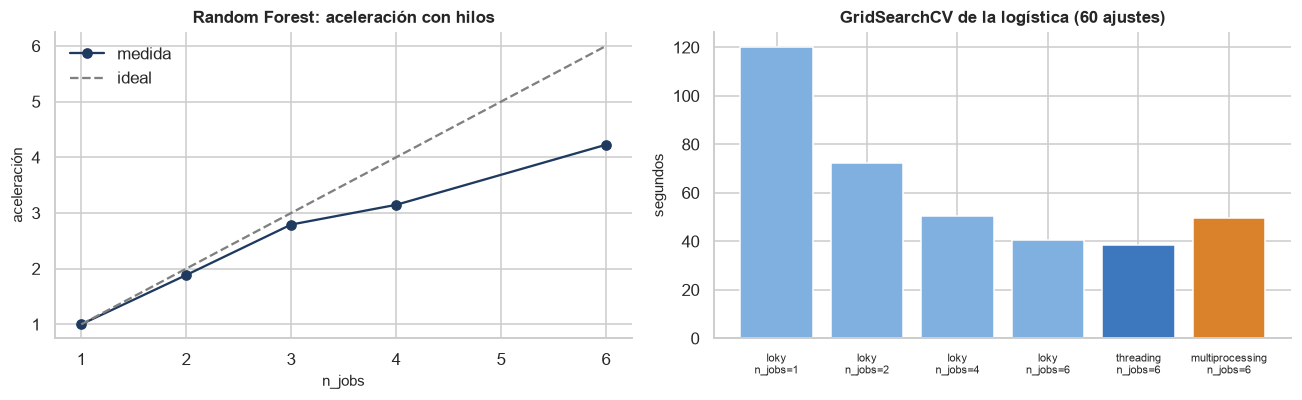

tiempo_s
experimento                                backend         n_jobs          
Random Forest (300 árboles)                hilos nativos   1        78.5477
                                                           2        41.6654
                                                           3        28.1344
                                                           4        24.9660
                                                           6        18.5886
GridSearchCV logística L1 (12 × 5 ajustes) loky            1       120.2996
                                                           2        72.3947
                                                           4        50.3577
                                                           6        40.6293
                                           threading       6        38.5717
                                           multiprocessing 6        49.5163


Random Forest acelera 4,2 veces con 6 hilos: según la ley de Amdahl, el 92 % de su trabajo es
paralelizable (los árboles son independientes; lo secuencial es preparar los datos y combinar). En la
búsqueda en rejilla, `loky` con 6 procesos tarda 40,63 s frente a 120,30 s en serie;
`threading` tarda 38,57 s, porque liblinear libera el GIL y los hilos evitan copiar los datos a cada
proceso; y `multiprocessing` tarda 49,52 s, porque en Windows cada proceso arranca un intérprete
nuevo. La elección del *backend* depende de si el trabajo libera el GIL: para los modelos de
`scikit-learn` escritos en C o Cython, los hilos son la opción más barata.


In [9]:
par = leer('paralelismo')
if par is not None:
    rf = par[par['experimento'].str.startswith('Random Forest')].set_index('n_jobs')['tiempo_s']
    acel = rf.loc[1] / rf
    fraccion = 1 - (1 / acel.loc[6] - 1 / 6) / (1 - 1 / 6)          # Amdahl: aceleración = 1 / ((1 − f) + f/N)
    gs = par[par['experimento'].str.startswith('GridSearch')]
    fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
    ax[0].plot(acel.index, acel.values, marker='o', color=graficos.AZUL, label='medida')
    ax[0].plot(acel.index, acel.index, ls='--', color='grey', label='ideal')
    ax[0].set_xlabel('n_jobs')
    ax[0].set_ylabel('aceleración')
    ax[0].set_title('Random Forest: aceleración con hilos')
    ax[0].legend(frameon=False)
    etiquetas = [f'{b}\nn_jobs={n}' for b, n in zip(gs['backend'], gs['n_jobs'])]
    ax[1].bar(etiquetas, gs['tiempo_s'], color=['#7fb0e0'] * 4 + ['#3d78bf', '#d9822b'])
    ax[1].set_ylabel('segundos')
    ax[1].set_title('GridSearchCV de la logística (60 ajustes)')
    ax[1].tick_params(axis='x', labelsize=7)
    plt.tight_layout()
    plt.show()
    display(par.set_index(['experimento', 'backend', 'n_jobs']))
    t = gs.set_index(['backend', 'n_jobs'])['tiempo_s']
    display(Markdown(f"""
Random Forest acelera {dec(acel.loc[6], 1)} veces con 6 hilos: según la ley de Amdahl, el {pct(fraccion, 0)} de su trabajo es
paralelizable (los árboles son independientes; lo secuencial es preparar los datos y combinar). En la
búsqueda en rejilla, `loky` con 6 procesos tarda {dec(t[('loky', 6)], 2)} s frente a {dec(t[('loky', 1)], 2)} s en serie;
`threading` tarda {dec(t[('threading', 6)], 2)} s, porque liblinear libera el GIL y los hilos evitan copiar los datos a cada
proceso; y `multiprocessing` tarda {dec(t[('multiprocessing', 6)], 2)} s, porque en Windows cada proceso arranca un intérprete
nuevo. La elección del *backend* depende de si el trabajo libera el GIL: para los modelos de
`scikit-learn` escritos en C o Cython, los hilos son la opción más barata.
"""))

### Paralelizar entre modelos y cómputo distribuido

La guía (§4.3) pide paralelizar también *entre* modelos, no solo entre pliegues. El experimento
reparte los 6 núcleos de cuatro maneras para hacer las mismas cuatro búsquedas en rejilla de
modelos distintos.

In [10]:
em = leer('entre_modelos')
if em is not None:
    em = em.set_index('esquema')
    em['aceleración frente a la serie'] = em.loc['todo en serie (1 núcleo)', 'tiempo_s'] / em['tiempo_s']
    display(em)
    mejor_esq = em['tiempo_s'].idxmin()
    total_h = None
    try:
        from src import analisis
        total_h = analisis.cargar_tabla().query("estado == 'ok' and modelo != 'ebm'")['tiempo_total_s'].sum() / 3600
    except Exception:
        pass
    dentro_gana = mejor_esq.startswith('dentro')
    display(Markdown(f"""
El esquema más rápido fue **{mejor_esq}** ({dec(em.loc[mejor_esq, 'tiempo_s'], 1)} s, {dec(em.loc[mejor_esq, 'aceleración frente a la serie'], 1)} veces más rápido
que en serie). {('Cada búsqueda tiene 8 configuraciones × 3 pliegues = 24 tareas, más que núcleos, así que paralelizar dentro de cada una ya mantiene ocupados los 6 núcleos; paralelizar entre modelos, en cambio, usa solo 4 procesos y queda a la espera del modelo más lento (el árbol y la logística tardan mucho más que Naive Bayes). Paralelizar entre modelos compensa cuando cada modelo tiene pocas tareas internas o cuando hay más núcleos que tareas por modelo.' if dentro_gana else 'Combinar los dos niveles equilibra mejor la carga: ninguno de los dos, por separado, mantiene los 6 núcleos ocupados todo el tiempo.')}
En las 140 corridas se paralelizó dentro de cada corrida (pliegues × configuraciones), porque cada corrida
tiene cientos de tareas y ya ocupaba los 6 núcleos; las corridas iban en serie para que los tiempos por
evaluación de cada optimizador no se contaminaran entre sí, que es lo que compara la sección de
optimizadores.

**Dask y Ray.** Las 140 combinaciones son independientes entre sí, de modo que el problema es perfectamente
paralelizable entre máquinas: con Ray (`ray.remote` sobre la función de una corrida) o con el *backend* de
Dask para joblib, {f"las {dec(total_h, 1)} horas de cómputo de este equipo" if total_h else "el tiempo total"} se dividirían casi linealmente entre los
nodos de un clúster. No se usaron porque el conjunto cabe en la memoria de un solo equipo (unos 30 MB tras el
preprocesamiento) y el plazo admitía un día de cómputo; con más datos, o con el producto completo repetido
para varias semillas, serían el siguiente paso natural.
"""))

,tiempo_s,aceleración frente a la serie
esquema,,
todo en serie (1 núcleo),64.6990,1.0000
"dentro de cada modelo (n_jobs=6), modelos en serie",24.7223,2.6170
"entre modelos (4 a la vez, n_jobs=1 dentro)",44.2086,1.4635
mixto (2 modelos a la vez × n_jobs=3 dentro),27.5029,2.3524



El esquema más rápido fue **dentro de cada modelo (n_jobs=6), modelos en serie** (24,7 s, 2,6 veces más rápido
que en serie). Cada búsqueda tiene 8 configuraciones × 3 pliegues = 24 tareas, más que núcleos, así que paralelizar dentro de cada una ya mantiene ocupados los 6 núcleos; paralelizar entre modelos, en cambio, usa solo 4 procesos y queda a la espera del modelo más lento (el árbol y la logística tardan mucho más que Naive Bayes). Paralelizar entre modelos compensa cuando cada modelo tiene pocas tareas internas o cuando hay más núcleos que tareas por modelo.
En las 140 corridas se paralelizó dentro de cada corrida (pliegues × configuraciones), porque cada corrida
tiene cientos de tareas y ya ocupaba los 6 núcleos; las corridas iban en serie para que los tiempos por
evaluación de cada optimizador no se contaminaran entre sí, que es lo que compara la sección de
optimizadores.

**Dask y Ray.** Las 140 combinaciones son independientes entre sí, de modo que el problema es perfectamente
paralelizable entre máquinas: con Ray (`ray.remote` sobre la función de una corrida) o con el *backend* de
Dask para joblib, las 26,9 horas de cómputo de este equipo se dividirían casi linealmente entre los
nodos de un clúster. No se usaron porque el conjunto cabe en la memoria de un solo equipo (unos 30 MB tras el
preprocesamiento) y el plazo admitía un día de cómputo; con más datos, o con el producto completo repetido
para varias semillas, serían el siguiente paso natural.


## 8. Perfil de una validación cruzada

`cProfile` sobre una validación cruzada de 3 pliegues del pipeline completo con SMOTE y XGBoost.

In [11]:
perfil = leer('perfil')
if perfil is not None:
    total = perfil['acumulado_s'].max()
    componentes = {
        'preprocesado (ColumnTransformer)': perfil[perfil['archivo'].eq('_column_transformer.py') & perfil['funcion'].isin(['fit_transform', 'transform'])],
        'SMOTE (fit_resample)': perfil[perfil['funcion'].eq('fit_resample')],
        'XGBoost (entrenamiento)': perfil[perfil['archivo'].isin(['sklearn.py', 'training.py', 'core.py']) & perfil['funcion'].isin(['fit', 'train', 'update'])],
        'puntuación (predict_proba y AUC)': perfil[perfil['funcion'].isin(['predict_proba', 'roc_auc_score'])],
    }
    resumen = pd.Series({k: v['acumulado_s'].max() if len(v) else np.nan for k, v in componentes.items()})
    display((resumen / total).to_frame('fracción del tiempo total').assign(segundos=resumen))
    utiles = perfil[~perfil['archivo'].isin(['parallel.py', '_param_validation.py', '_validation.py'])]
    display(utiles.head(15))
    cuota = (resumen / total).dropna()
    display(Markdown(f"""
De los {dec(total, 1)} s de la validación cruzada, {enumerar(f"{k} se lleva el {pct(v, 0)}" for k, v in cuota.sort_values(ascending=False).items())}.
El cuello de botella es el ajuste del modelo, no la preparación de los datos ni el remuestreo: optimizar
el pipeline pasa por el modelo (método `hist`, menos árboles con *early stopping*, multi-fidelidad), que es
lo que se hizo.
"""))
    print((CARPETA / 'perfil.txt').read_text(encoding='utf-8')[:3000])

,fracción del tiempo total,segundos
preprocesado (ColumnTransformer),0.0628,0.8840
SMOTE (fit_resample),0.0951,1.3389
XGBoost (entrenamiento),0.7925,11.1571
puntuación (predict_proba y AUC),0.0199,0.2802


,funcion,archivo,llamadas,propio_s,acumulado_s,fraccion_del_total
8,wrapper,base.py,18,0.0185,13.4036,0.9520
9,fit,pipeline.py,3,0.0003,13.3974,0.9516
10,inner_f,core.py,45,0.0006,11.1910,0.7949
11,fit,sklearn.py,3,0.0002,11.1571,0.7925
12,train,training.py,3,0.0035,10.5274,0.7477
13,update,core.py,435,10.3620,10.4430,0.7417
14,_fit,pipeline.py,3,0.0085,2.2377,0.1589
15,__call__,memory.py,6,0.0000,2.2284,0.1583
16,_fit_resample_one,pipeline.py,3,0.0000,1.3389,0.0951
17,fit_resample,base.py,3,0.0000,1.3389,0.0951



De los 14,1 s de la validación cruzada, XGBoost (entrenamiento) se lleva el 79 %, SMOTE (fit_resample) se lleva el 10 %, preprocesado (ColumnTransformer) se lleva el 6 % y puntuación (predict_proba y AUC) se lleva el 2 %.
El cuello de botella es el ajuste del modelo, no la preparación de los datos ni el remuestreo: optimizar
el pipeline pasa por el modelo (método `hist`, menos árboles con *early stopping*, multi-fidelidad), que es
lo que se hizo.


         252863 function calls (247908 primitive calls) in 14.079 seconds

   Ordered by: cumulative time
   List reduced from 1287 to 25 due to restriction <25>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
     24/1    0.000    0.000   14.079   14.079 D:\Ruben\universidad\machine_learning\entrega 3\.venv\Lib\site-packages\sklearn\utils\_param_validation.py:187(wrapper)
        1    0.000    0.000   14.078   14.078 D:\Ruben\universidad\machine_learning\entrega 3\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:496(cross_val_score)
        1    0.000    0.000   14.077   14.077 D:\Ruben\universidad\machine_learning\entrega 3\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:75(cross_validate)
      7/1    0.000    0.000   14.071   14.071 D:\Ruben\universidad\machine_learning\entrega 3\.venv\Lib\site-packages\sklearn\utils\parallel.py:54(__call__)
      7/1    0.000    0.000   14.071   14.071 D:\Ruben\universidad\machine_learning\entr

## 9. ¿Es válida la multi-fidelidad?

La multi-fidelidad de la búsqueda supone que la versión barata (100 árboles en Random Forest, 2 bolsas
en la EBM) ordena las configuraciones igual que la cara (300 árboles, 8 bolsas). Se comprueba con
configuraciones aleatorias del espacio de búsqueda, evaluadas con las dos fidelidades y la misma
validación cruzada de 3 pliegues.

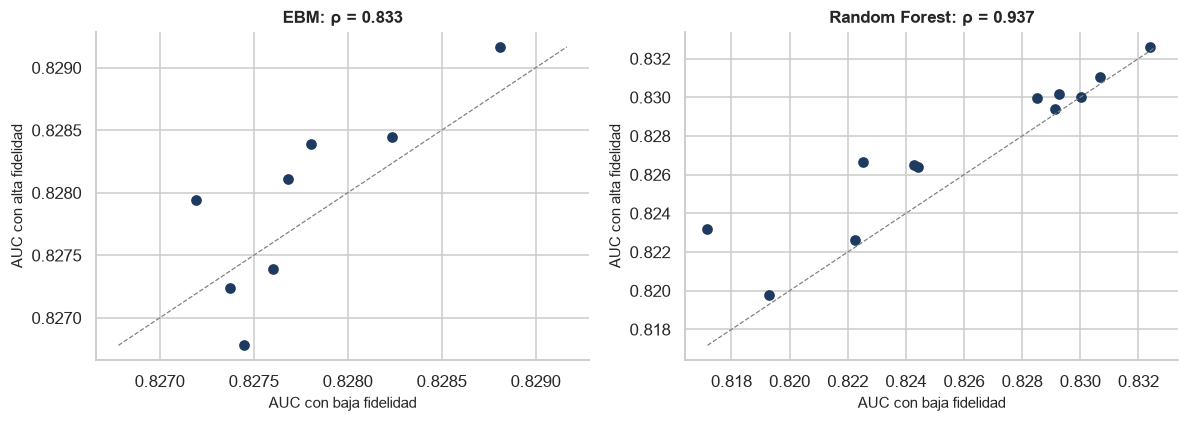

,configuraciones,ρ de Spearman baja/alta,misma mejor configuración,pérdida al elegir con baja fidelidad,ahorro de tiempo
modelo,,,,,
EBM,8,0.8333,True,0.0000,0.6553
Random Forest,12,0.9371,True,0.0000,0.6515



El orden se conserva: la correlación de Spearman entre los AUC con fidelidad baja y alta es de
0,833 en EBM y 0,937 en Random Forest.
La configuración ganadora es la misma con las dos fidelidades en los dos modelos,
y la fidelidad baja ahorra el 65 % o más del tiempo de búsqueda. La multi-fidelidad de las
corridas está justificada.


In [12]:
fid = leer('fidelidad')
if fid is not None:
    filas = []
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    for a, (m, g) in zip(ax, fid.groupby('modelo')):
        rho = stats.spearmanr(g['auc_baja'], g['auc_alta']).statistic
        mismo_mejor = g['auc_baja'].idxmax() == g['auc_alta'].idxmax()
        filas.append({'modelo': NOMBRES_MODELO[m], 'configuraciones': len(g), 'ρ de Spearman baja/alta': rho,
                      'misma mejor configuración': mismo_mejor,
                      'pérdida al elegir con baja fidelidad': g['auc_alta'].max() - g.loc[g['auc_baja'].idxmax(), 'auc_alta'],
                      'ahorro de tiempo': 1 - g['tiempo_baja_s'].sum() / g['tiempo_alta_s'].sum()})
        a.scatter(g['auc_baja'], g['auc_alta'], color=graficos.AZUL)
        lim = [min(g['auc_baja'].min(), g['auc_alta'].min()), max(g['auc_baja'].max(), g['auc_alta'].max())]
        a.plot(lim, lim, ls='--', color='grey', lw=0.8)
        a.set_xlabel('AUC con baja fidelidad')
        a.set_ylabel('AUC con alta fidelidad')
        a.set_title(f'{NOMBRES_MODELO[m]}: ρ = {rho:.3f}')
    plt.tight_layout()
    plt.show()
    fidelidad = pd.DataFrame(filas).set_index('modelo')
    display(fidelidad)
    perdida = fidelidad['pérdida al elegir con baja fidelidad'].max()
    display(Markdown(f"""
El orden se conserva: la correlación de Spearman entre los AUC con fidelidad baja y alta es de
{enumerar(f"{dec(r['ρ de Spearman baja/alta'], 3)} en {m.replace(' (modelo nuevo)', '')}" for m, r in fidelidad.iterrows())}.
{'La configuración ganadora es la misma con las dos fidelidades en los dos modelos' if perdida <= 1e-9 else 'Elegir con la fidelidad baja cuesta como máximo ' + dec(perdida, 4) + ' de AUC frente a elegir con la alta'},
y la fidelidad baja ahorra el {pct(fidelidad['ahorro de tiempo'].min(), 0)} o más del tiempo de búsqueda. La multi-fidelidad de las
corridas está justificada.
"""))

## 10. Tabla resumen: versión estándar frente a versión optimizada

In [13]:
filas = []

def fila(modelo, estandar, optimizada, complejidad, t_e, t_o, i_e=np.nan, i_o=np.nan, mem_e=np.nan, mem_o=np.nan,
         met_e=np.nan, met_o=np.nan, metrica='AUC'):
    filas.append({'modelo': modelo, 'versión estándar': estandar, 'versión optimizada': optimizada,
                  'complejidad (estándar → optimizada)': complejidad, 'entrenamiento estándar (s)': t_e,
                  'entrenamiento optimizado (s)': t_o, 'aceleración del entrenamiento': t_e / t_o if t_o else np.nan,
                  'inferencia estándar (s)': i_e, 'inferencia optimizada (s)': i_o,
                  'memoria estándar (MB)': mem_e, 'memoria optimizada (MB)': mem_o,
                  'métrica': metrica, 'estándar': met_e, 'optimizada': met_o, 'cambio en la métrica': met_o - met_e})

if knn is not None:
    k = knn[knn['dimension'] == '78 variables'].set_index('metodo')
    fila('k-NN', 'scikit-learn, fuerza bruta', 'FAISS IndexFlat', 'O(n·m·p) → O(n·m·p) vectorizado',
         k.loc['scikit-learn brute', 'construccion_s'], k.loc['FAISS IndexFlat (exacto)', 'construccion_s'],
         k.loc['scikit-learn brute', 'consulta_s'], k.loc['FAISS IndexFlat (exacto)', 'consulta_s'],
         k.loc['scikit-learn brute', 'indice_mb'], k.loc['FAISS IndexFlat (exacto)', 'indice_mb'],
         k.loc['scikit-learn brute', 'auc'], k.loc['FAISS IndexFlat (exacto)', 'auc'])
    hnsw = [i for i in k.index if 'HNSW' in i]
    if hnsw:
        fila('k-NN', 'scikit-learn, fuerza bruta', 'FAISS HNSW (aproximado)', 'O(n·m·p) → O(m·log n·p)',
             k.loc['scikit-learn brute', 'construccion_s'], k.loc[hnsw[0], 'construccion_s'],
             k.loc['scikit-learn brute', 'consulta_s'], k.loc[hnsw[0], 'consulta_s'],
             k.loc['scikit-learn brute', 'indice_mb'], k.loc[hnsw[0], 'indice_mb'],
             k.loc['scikit-learn brute', 'auc'], k.loc[hnsw[0], 'auc'])
if knn is not None:
    k4 = knn[knn['dimension'] == '4 variables con señal'].set_index('metodo')
    fila('k-NN', '78 variables, fuerza bruta', '4 variables con señal, KD-Tree', "O(n·m·p) → O(m·log n·p') con p' = 4",
         k.loc['scikit-learn brute', 'construccion_s'], k4.loc['scikit-learn kd_tree', 'construccion_s'],
         k.loc['scikit-learn brute', 'consulta_s'], k4.loc['scikit-learn kd_tree', 'consulta_s'],
         k.loc['scikit-learn brute', 'indice_mb'], k4.loc['scikit-learn kd_tree', 'indice_mb'],
         k.loc['scikit-learn brute', 'auc'], k4.loc['scikit-learn kd_tree', 'auc'])
if lin is not None:
    r = lin[lin['modelo'] == 'Ridge'].set_index('solucionador')
    fila('Ridge', 'SAGA', f"{r['entrenamiento_s'].idxmin()} (directo)", 'O(k·n·p) → O(n·p² + p³)',
         r.loc['saga', 'entrenamiento_s'], r['entrenamiento_s'].min(), met_e=r.loc['saga', 'valor'],
         met_o=r.loc[r['entrenamiento_s'].idxmin(), 'valor'], metrica='RMSE')
    l = lin[lin['modelo'] == 'Lasso'].set_index('solucionador')
    fila('Lasso', 'SGD con L1', 'descenso por coordenadas', 'O(k·n·p) en los dos',
         l.loc['SGD con penalización L1', 'entrenamiento_s'], l.loc['descenso por coordenadas', 'entrenamiento_s'],
         met_e=l.loc['SGD con penalización L1', 'valor'], met_o=l.loc['descenso por coordenadas', 'valor'], metrica='RMSE')
if nb is not None:
    fila('Naive Bayes', 'fit completo', 'partial_fit en lotes de 5.000', 'O(n·p) en los dos; memoria O(lote·p)',
         nb.iloc[0]['entrenamiento_s'], nb.iloc[2]['entrenamiento_s'], mem_e=nb.iloc[0]['memoria_mb'],
         mem_o=nb.iloc[2]['memoria_mb'], met_e=nb.iloc[0]['auc'], met_o=nb.iloc[2]['auc'])
if xg is not None:
    m = xg[xg['experimento'] == 'método y dispositivo'].set_index('variante')
    ex = m[m.index.str.startswith('exact')].iloc[0]
    hi = m.loc['hist · cpu · todos los hilos']
    gp = m[m.index.str.contains('cuda')].iloc[0]
    fila('XGBoost', 'exact (CPU)', 'hist (CPU)', 'O(T·d·n·p·log n) → O(T·d·(n·p + bins·p))',
         ex['entrenamiento_s'], hi['entrenamiento_s'], ex['inferencia_s'], hi['inferencia_s'], met_e=ex['auc'], met_o=hi['auc'])
    fila('XGBoost', 'hist (CPU, 6 hilos)', 'hist (GPU RTX 3050)', 'igual, en otro dispositivo',
         hi['entrenamiento_s'], gp['entrenamiento_s'], hi['inferencia_s'], gp['inferencia_s'], met_e=hi['auc'], met_o=gp['auc'])
    es = xg[xg['experimento'] == 'early stopping'].reset_index(drop=True)
    fila('XGBoost', '500 árboles fijos', f"early stopping ({es.loc[1, 'arboles']:.0f} árboles)", 'O(T) → O(T*), T* < T',
         es.loc[0, 'entrenamiento_s'], es.loc[1, 'entrenamiento_s'], met_e=es.loc[0, 'auc'], met_o=es.loc[1, 'auc'])
if svm is not None and len(rbf):
    fila('SVM', 'SVC núcleo RBF (extrapolado a n)', 'LinearSVC primal', 'O(n²·p)–O(n³) → O(k·n·p)',
         extrapolado, lineal['entrenamiento_s'], met_e=rbf_max['auc'], met_o=lineal['auc'])
if par is not None:
    fila('Random Forest', 'n_jobs = 1', 'n_jobs = 6', 'O(T·n·p·log n) repartido en 6 núcleos', rf.loc[1], rf.loc[6])
if fid is not None:
    for m, g in fid.groupby('modelo'):
        fila(NOMBRES_MODELO[m], 'búsqueda con fidelidad alta', 'búsqueda con fidelidad baja (multi-fidelidad)',
             'O(T) → O(T/3) en Random Forest; O(B) → O(B/4) en la EBM', g['tiempo_alta_s'].sum(), g['tiempo_baja_s'].sum(),
             met_e=g['auc_alta'].max(), met_o=g.loc[g['auc_baja'].idxmax(), 'auc_alta'])
if filas:
    tabla_comp = pd.DataFrame(filas).set_index(['modelo', 'versión estándar', 'versión optimizada'])
    display(tabla_comp)
else:
    display(Markdown('*La tabla se completa cuando terminen los experimentos.*'))

complejidad (estándar → optimizada)  \
modelo        versión estándar                 versión optimizada                                                                                 
k-NN          scikit-learn, fuerza bruta       FAISS IndexFlat                                                  O(n·m·p) → O(n·m·p) vectorizado   
                                               FAISS HNSW (aproximado)                                                  O(n·m·p) → O(m·log n·p)   
              78 variables, fuerza bruta       4 variables con señal, KD-Tree                               O(n·m·p) → O(m·log n·p') con p' = 4   
Ridge         SAGA                             cholesky (directo)                                                       O(k·n·p) → O(n·p² + p³)   
Lasso         SGD con L1                       descenso por coordenadas                                                     O(k·n·p) en los dos   
Naive Bayes   fit completo                     partial_fit en lotes de 5.000                               O(n·p) en los dos; memoria O(lote·p)   
XGBoost       exact (CPU)                      hist (CPU)                                              O(T·d·n·p·log n) → O(T·d·(n·p + bins·p))   
              hist (CPU, 6 hilos)              hist (GPU RTX 3050)                                                   igual, en otro dispositivo   
              500 árboles fijos                early stopping (153 árboles)                                                O(T) → O(T*), T* < T   
SVM           SVC núcleo RBF (extrapolado a n) LinearSVC primal                                                        O(n²·p)–O(n³) → O(k·n·p)   
Random Forest n_jobs = 1                       n_jobs = 6                                                 O(T·n·p·log n) repartido en 6 núcleos   
EBM           búsqueda con fidelidad alta      búsqueda con fidelidad baja (multi-fidelidad)  O(T) → O(T/3) en Random Forest; O(B) → O(B/4) ...   
Random Forest búsqueda con fidelidad alta      búsqueda con fidelidad baja (multi-fidelidad)  O(T) → O(T/3) en Random Forest; O(B) → O(B/4) ...   

                                                                                              entrenamiento estándar (s)  \
modelo        versión estándar                 versión optimizada                                                          
k-NN          scikit-learn, fuerza bruta       FAISS IndexFlat                                                    0.0033   
                                               FAISS HNSW (aproximado)                                            0.0033   
              78 variables, fuerza bruta       4 variables con señal, KD-Tree                                     0.0033   
Ridge         SAGA                             cholesky (directo)                                                15.0818   
Lasso         SGD con L1                       descenso por coordenadas                                           0.8792   
Naive Bayes   fit completo                     partial_fit en lotes de 5.000                                      0.0462   
XGBoost       exact (CPU)                      hist (CPU)                                                         5.7574   
              hist (CPU, 6 hilos)              hist (GPU RTX 3050)                                                0.8245   
              500 árboles fijos                early stopping (153 árboles)                                       2.7219   
SVM           SVC núcleo RBF (extrapolado a n) LinearSVC primal                                                  43.1122   
Random Forest n_jobs = 1                       n_jobs = 6                                                        78.5477   
EBM           búsqueda con fidelidad alta      búsqueda con fidelidad baja (multi-fidelidad)                    306.5848   
Random Forest búsqueda con fidelidad alta      búsqueda con fidelidad baja (multi-fidelidad)                    280.0975   

                                         